In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
w1_familybackground = pd.read_csv('../tab/safeguarded_eul/wave_one_lsype_family_background_2020.tab', sep="\t")
w1_parentalattitude = pd.read_csv('../tab/safeguarded_eul/wave_one_lsype_parental_attitudes_file_16_05_08.tab', sep="\t")
w1_youngperson = pd.read_csv('../tab/safeguarded_eul/wave_one_lsype_young_person_2020.tab', sep="\t")
w1_merged = w1_familybackground.merge(w1_youngperson, on='NSID', how='inner').merge(w1_parentalattitude, on='NSID', how='inner')

In [46]:
w2_familybackground = pd.read_csv('../tab/safeguarded_eul/wave_two_lsype_family_background_2020.tab', sep="\t")
w2_parentalattitude = pd.read_csv('../tab/safeguarded_eul/wave_two_lsype_parental_attitudes_file_16_06_08.tab', sep="\t")
w2_youngperson = pd.read_csv('../tab/safeguarded_eul/wave_two_lsype_young_person_2020.tab', sep="\t")
w2_merged = w2_familybackground.merge(w2_youngperson, on='NSID', how='inner').merge(w2_parentalattitude, on='NSID', how='inner')

In [47]:
w3_familybackground = pd.read_csv('../tab/safeguarded_eul/wave_three_lsype_family_background_2020.tab', sep="\t")
w3_parentalattitude = pd.read_csv('../tab/safeguarded_eul/wave_three_lsype_parental_attitudes_file_16_06_08.tab', sep="\t")
w3_youngperson = pd.read_csv('../tab/safeguarded_eul/wave_three_lsype_young_person_2020.tab', sep="\t")
w3_merged = w3_familybackground.merge(w3_youngperson, on='NSID', how='inner').merge(w3_parentalattitude, on='NSID', how='inner')

In [48]:
w4_familybackground = pd.read_csv('../tab/safeguarded_eul/wave_four_lsype_family_background_2020.tab', sep="\t")
w4_parentalattitude = pd.read_csv('../tab/safeguarded_eul/wave_four_lsype_parental_attitudes_june_2009.tab', sep="\t")
w4_youngperson = pd.read_csv('../tab/safeguarded_eul/wave_four_lsype_young_person_2020.tab', sep="\t")
w4_merged = w4_familybackground.merge(w4_youngperson, on='NSID', how='inner').merge(w4_parentalattitude, on='NSID', how='inner')

In [49]:
w5_familybackground = pd.read_csv('../tab/safeguarded_eul/wave_five_lsype_family_background_2020.tab', sep="\t")
w5_youngperson = pd.read_csv('../tab/safeguarded_eul/wave_five_lsype_young_person_2020.tab', sep="\t")
w5_activityhistory = pd.read_csv('../tab/activity_histories/wave_five_activity_history_file_2020.tab', sep="\t")
w5_merged = w5_familybackground.merge(w5_youngperson, on='NSID', how='inner')

In [50]:
# w6 onwards - no family background
# exclude w6_activityhistory due to severe lack of data
w6_youngperson = pd.read_csv('../tab/safeguarded_eul/wave_six_lsype_young_person_2020.tab', sep="\t")
w6_merged = w6_youngperson

In [51]:
w7_youngperson = pd.read_csv('../tab/safeguarded_eul/wave_seven_lsype_young_person_2020.tab', sep="\t")
w7_activityhistory = pd.read_csv('../tab/activity_histories/wave_seven_activity_history_file_2020.tab', sep="\t")
w7_merged = w7_youngperson

In [52]:
w8_maininterview = pd.read_csv('../tab/safeguarded_eul/ns8_2015_main_interview.tab', sep="\t")
w8_selfcompletion = pd.read_csv('../tab/safeguarded_eul/ns8_2015_self_completion.tab', sep="\t")
w8_derived = pd.read_csv('../tab/safeguarded_eul/ns8_2015_derived.tab', sep="\t")
w8_merged = w8_maininterview.merge(w8_selfcompletion, on='NSID', how='inner').merge(w8_derived, on='NSID', how='inner')

In [53]:
w9_maininterview = pd.read_csv('../tab/safeguarded_eul/ns9_2022_main_interview.tab', sep="\t")
w9_derived_vars = pd.read_csv('../tab/safeguarded_eul/ns9_2022_derived_variables.tab', sep="\t")
w9_merged = w9_maininterview.merge(w9_derived_vars, on='NSID', how='inner')

In [54]:
# Exclude unemployed persons
w9_merged = w9_merged[w9_merged['W9DWRK'] == 1]

# Exclude datapoints without income
w9_merged = w9_merged[w9_merged['W9GROA'] > 0 ]

In [55]:
len(w9_merged)

4897

In [56]:
# Post process income
w9_merged['W9PAY'] = np.where(
    w9_merged['W9GROP2'] == 1, w9_merged['W9GROA'] * 52,
    np.where(
        w9_merged['W9GROP2'] == 2, w9_merged['W9GROA'] * 12,
        np.where(w9_merged['W9GROP2'] == 3, w9_merged['W9GROA'], None)
    )
)

w9_merged = w9_merged[w9_merged['W9PAY'].isna() == False] 

In [57]:
# Example: keep 'SampPSU' and 'SampStratum' in w9_merged only
w1_merged = w1_merged.drop(['SampPSU', 'SampStratum'], axis=1)
w2_merged = w2_merged.drop(['SampPSU', 'SampStratum'], axis=1)
w4_merged = w4_merged.drop(['SampPSU', 'SampStratum'], axis=1)

all_waves_merged = (
    w9_merged
    .merge(w1_merged, on='NSID', how='inner')
    .merge(w2_merged, on='NSID', how='inner')
    .merge(w3_merged, on='NSID', how='inner')
    .merge(w4_merged, on='NSID', how='inner')
    .merge(w5_merged, on='NSID', how='inner')
    .merge(w6_merged, on='NSID', how='inner')
    .merge(w7_merged, on='NSID', how='inner')
    .merge(w8_merged, on='NSID', how='inner')
)

In [58]:
# Identify B40
b40_mask1 = (all_waves_merged['W1inc1est'] >= 0) & (all_waves_merged['W1inc1est'] < 21)
b40_mask2 = (all_waves_merged['W1inc1estMP'] >= 0) & (all_waves_merged['W1inc1estMP'] < 21)
b40_mask3 = (all_waves_merged['W2GrssyrHHbands'] >= 0) & (all_waves_merged['W2GrssyrHHbands'] < 4)
b40_mask4 = (all_waves_merged['W3incestMP'] >= 0) & (all_waves_merged['W3incestMP'] < 5)
b40_mask5 = (all_waves_merged['W4Inc1EstMP'] >= 0) & (all_waves_merged['W4Inc1EstMP'] < 5)

combined_b40_mask = b40_mask1 | b40_mask2 | b40_mask3 | b40_mask4 | b40_mask5

all_waves_merged['is_b40'] = np.where(combined_b40_mask, 1, 0)
all_waves_merged['is_b40'].value_counts()

C:\Users\user\AppData\Local\Temp\ipykernel_112824\3464087160.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_waves_merged['is_b40'] = np.where(combined_b40_mask, 1, 0)


0    1866
1    1113
Name: is_b40, dtype: int64

In [59]:
# Group w9 income into quantile
conditions = [
    (all_waves_merged['W9PAY'] <= 18500),                                          # 20
    (all_waves_merged['W9PAY'] > 18500) & (all_waves_merged['W9PAY'] <= 24700),    # 40
    (all_waves_merged['W9PAY'] > 24700) & (all_waves_merged['W9PAY'] <= 32900),    # 60
    (all_waves_merged['W9PAY'] > 32900) & (all_waves_merged['W9PAY'] <= 47900),    # 80
    (all_waves_merged['W9PAY'] > 47900)                                            # 80+
]

choices = [1, 2, 3, 4, 5]

all_waves_merged['W9_income_cat'] = np.select(conditions, choices, default=np.nan)
print(all_waves_merged['W9_income_cat'].value_counts()/len(all_waves_merged))


4.0    0.266868
5.0    0.244042
3.0    0.189997
2.0    0.150386
1.0    0.148708
Name: W9_income_cat, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_112824\1572950400.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_waves_merged['W9_income_cat'] = np.select(conditions, choices, default=np.nan)


In [60]:
all_waves_merged['W9_income_cat'].shape

(2979,)

In [61]:
b40 = all_waves_merged[all_waves_merged['is_b40']==1]
b40.shape

(1113, 10287)

In [62]:
b40.loc[:, 'pi_above_med'] = b40['W9_income_cat'] >= 3
b40['pi_above_med'].value_counts().sum()

C:\Users\user\AppData\Local\Temp\ipykernel_112824\2824209080.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b40.loc[:, 'pi_above_med'] = b40['W9_income_cat'] >= 3


1113

In [63]:
b40.shape

(1113, 10288)

In [64]:
b40.columns = b40.columns.str.lower()

Processing predictors

In [65]:
bullying_columns = [
    "w2pbull1mp0a", "w2pbull1mp0b", "w2pbull1mp0c", "w2pbull1mp0d",
    "w2pbull1mp0e", "w2pbull1mp0f", "w2pbull1mp0g", "w2pbull1mp0h",
    "w3pbull1mp0a", "w3pbull1mp0b", "w3pbull1mp0c", "w3pbull1mp0d",
    "w3pbull1mp0e", "w3pbull1mp0f", "w3pbull1mp0g", "w3pbull1mp0h",
    "w3pbull1mp0i", "w3pbull1mp0j", "w3pbull1mp0k"
]

# b40_temp["bullied"] = (b40_temp[bullying_columns] == 1).sum(axis=1)
b40["bullied"] = round((b40[bullying_columns] == 1).sum(axis=1) / len(bullying_columns), 5)

C:\Users\user\AppData\Local\Temp\ipykernel_112824\794496912.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b40["bullied"] = round((b40[bullying_columns] == 1).sum(axis=1) / len(bullying_columns), 5)


In [66]:
b40['bullied'].value_counts()

0.05263    714
0.10526    155
0.00000    104
0.15789     48
0.21053     38
0.26316     22
0.31579     15
0.36842     10
0.42105      3
0.47368      3
0.52632      1
Name: bullied, dtype: int64

In [67]:
b40["truant"] = (b40[['w2truantyp', 'w3truantyp']] == 1).any(axis=1).astype(int)

C:\Users\user\AppData\Local\Temp\ipykernel_112824\1791144125.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b40["truant"] = (b40[['w2truantyp', 'w3truantyp']] == 1).any(axis=1).astype(int)


In [68]:
b40['truant'].value_counts()

0    815
1    298
Name: truant, dtype: int64

In [69]:
b40["marital_status_MP"] = b40[['w2marstatmp', 'w3marstatmp', 'w4marstatmp']].max(axis=1)


C:\Users\user\AppData\Local\Temp\ipykernel_112824\3037617475.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b40["marital_status_MP"] = b40[['w2marstatmp', 'w3marstatmp', 'w4marstatmp']].max(axis=1)


In [70]:
b40["marital_status_MP"].value_counts()

 2     653
 5     213
 4      83
 1      82
 6      59
 8      10
 3       9
-94      2
 7       1
-91      1
Name: marital_status_MP, dtype: int64

Relevelling predictors

In [28]:
def map_marital_status(value):
    if value == 1:
        return 1
    elif value >= 2 and value <= 3:
        return 2
    elif value >= 4 and value <= 7:
        return 3
    elif value == 8:
        return 4
    return value  # In case there are any unexpected values

# Apply the function to the column
b40['marital_status_MP'] = b40['marital_status_MP'].apply(map_marital_status)

C:\Users\user\AppData\Local\Temp\ipykernel_112824\2326185616.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b40['marital_status_MP'] = b40['marital_status_MP'].apply(map_marital_status)


In [29]:
def map_russell(value):
    if value == -1:
        return 3
    return value  # In case there are any unexpected values

# Apply the function to the column
b40['w9drussell'] = b40['w9drussell'].apply(map_russell)

C:\Users\user\AppData\Local\Temp\ipykernel_112824\2844587952.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b40['w9drussell'] = b40['w9drussell'].apply(map_russell)


In [30]:
def map_ethnic(value):
    if value >= 1 and value <= 3:
        return 1
    elif value >= 4 and value <= 7:
        return 2
    elif value >= 8 and value <= 11 or value == 15:
        return 3
    elif value >= 12 and value <= 14:
        return 4
    elif value == 16:
        return 5
    return value

# Apply the function to the column
b40['w2ethnicyp'] = b40['w2ethnicyp'].apply(map_ethnic)

C:\Users\user\AppData\Local\Temp\ipykernel_112824\3816061664.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b40['w2ethnicyp'] = b40['w2ethnicyp'].apply(map_ethnic)


In [31]:
def map_w2hiqualgmp(value):
    if value == 1:
        return 1
    elif value >= 2 and value <= 3:
        return 2
    elif value == 4:
        return 3
    elif value >= 5 and value <= 6:
        return 4
    elif value == 7:
        return 5
    return value  # In case there are any unexpected values

# Apply the function to the column
b40['w2hiqualgmp'] = b40['w2hiqualgmp'].apply(map_w2hiqualgmp)

C:\Users\user\AppData\Local\Temp\ipykernel_112824\1700220630.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b40['w2hiqualgmp'] = b40['w2hiqualgmp'].apply(map_w2hiqualgmp)


In [32]:
def map_w9danvqh(value):
    if value == 95 or value == 96:
        return 6
    return value  # In case there are any unexpected values

# Apply the function to the column
b40['w9danvqh'] = b40['w9danvqh'].apply(map_w9danvqh)

C:\Users\user\AppData\Local\Temp\ipykernel_112824\1881014182.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b40['w9danvqh'] = b40['w9danvqh'].apply(map_w9danvqh)


In [33]:
def map_w9dvnvqh(value):
    if value == 95 or value == 96:
        return 6
    return value  # In case there are any unexpected values

# Apply the function to the column
b40['w9dvnvqh'] = b40['w9dvnvqh'].apply(map_w9dvnvqh)

C:\Users\user\AppData\Local\Temp\ipykernel_112824\4084379680.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b40['w9dvnvqh'] = b40['w9dvnvqh'].apply(map_w9dvnvqh)


In [34]:
def map_w6univyp(value):
    if value == 2:
        return 0
    return value  # In case there are any unexpected values

# Apply the function to the column
b40['w6univyp'] = b40['w6univyp'].apply(map_w6univyp)

C:\Users\user\AppData\Local\Temp\ipykernel_112824\3611699865.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b40['w6univyp'] = b40['w6univyp'].apply(map_w6univyp)


In [35]:
def map_w2sexyp(value):
    if value == 2:
        return 0
    return value  # In case there are any unexpected values

# Apply the function to the column
b40['w2sexyp'] = b40['w2sexyp'].apply(map_w2sexyp)

C:\Users\user\AppData\Local\Temp\ipykernel_112824\3987445898.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b40['w2sexyp'] = b40['w2sexyp'].apply(map_w2sexyp)


In [71]:
b40["drugs"] = b40[['w6drugyp0a', 'w6drugyp0b', 'w7drugyp1yp0a', 'w7drugyp1yp0b']].max(axis=1)

C:\Users\user\AppData\Local\Temp\ipykernel_112824\3762948170.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b40["drugs"] = b40[['w6drugyp0a', 'w6drugyp0b', 'w7drugyp1yp0a', 'w7drugyp1yp0b']].max(axis=1)


In [72]:
b40["job_attd"] = b40[['w6paystatyp0d', 'w7paystatyp0d']].max(axis=1)

C:\Users\user\AppData\Local\Temp\ipykernel_112824\161128912.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b40["job_attd"] = b40[['w6paystatyp0d', 'w7paystatyp0d']].max(axis=1)


Selecting predictors

In [73]:
# List of variables to keep
selected_vars = [
    "idacirscore_y", "w2sexyp", "w4ghq12scr", "w2ethnicyp",
    "w2fat5yp", "bullied", "truant", "w2hiqualgmp", "w3outschbyp", "w7heflag",
    "w9danvqh", "w9dvnvqh", "w9drussell", "imdrscore_y",
    "gor_x", "marital_status_MP", "w4lnpar", "w3parqualmp",
    "w4readsyp", "w4concenyp", "w4noconfyp", "drugs", "job_attd", "w6univyp", 
    "w9_income_cat"  # outcome variable
]
# Subset the dataframe
b40 = b40[selected_vars]

In [74]:
b40[b40 < 0] = np.nan

Turn outcome into binary

In [79]:
conditions = [
    (b40['w9_income_cat'] <= 2),                                      # B40
    (b40['w9_income_cat'] > 2)                                        # T60
]

choices = [0, 1]

b40['w9_income_above_median'] = np.select(conditions, choices, default=np.nan)
print(b40['w9_income_above_median'].value_counts())

1.0    692
0.0    421
Name: w9_income_above_median, dtype: int64


In [80]:
b40 = b40.drop(['w9_income_cat'], axis=1)

In [81]:
# drop w5ethnicyp - level 5 due to only having 5 observations + same outcome
b40 = b40[b40['w2ethnicyp'] != 5]

In [43]:
b40.to_csv('preprocessed_data.csv', index=False)

In [85]:
b40

,idacirscore_y,w2sexyp,w4ghq12scr,w2ethnicyp,w2fat5yp,bullied,truant,w2hiqualgmp,w3outschbyp,w7heflag,...,marital_status_MP,w4lnpar,w3parqualmp,w4readsyp,w4concenyp,w4noconfyp,drugs,job_attd,w6univyp,w9_income_above_median
0,0.26,1.0,5.0,1.0,1.0,0.05263,0,4.0,2.0,2,...,2.0,2.0,4.0,1.0,2.0,3.0,0.0,1.0,2.0,1.0
1,0.38,1.0,0.0,1.0,2.0,0.05263,0,1.0,1.0,1,...,2.0,2.0,4.0,5.0,2.0,1.0,0.0,1.0,1.0,0.0
2,0.09,1.0,1.0,1.0,3.0,0.05263,1,4.0,2.0,2,...,5.0,1.0,1.0,3.0,2.0,2.0,0.0,3.0,2.0,1.0
3,0.28,1.0,1.0,8.0,1.0,0.05263,0,1.0,2.0,1,...,6.0,1.0,4.0,2.0,2.0,1.0,0.0,3.0,1.0,1.0
4,0.03,1.0,0.0,1.0,3.0,0.05263,0,1.0,1.0,1,...,2.0,2.0,2.0,3.0,2.0,2.0,0.0,3.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2967,0.32,1.0,5.0,15.0,NaN,0.00000,0,7.0,2.0,1,...,2.0,2.0,NaN,2.0,1.0,2.0,0.0,4.0,1.0,1.0
2969,0.07,1.0,0.0,1.0,2.0,0.05263,0,4.0,2.0,2,...,4.0,1.0,5.0,3.0,2.0,1.0,0.0,2.0,2.0,1.0
2970,0.10,2.0,0.0,1.0,3.0,0.31579,0,4.0,2.0,1,...,2.0,2.0,4.0,3.0,2.0,1.0,0.0,3.0,1.0,1.0
2974,0.05,1.0,0.0,1.0,3.0,0.10526,0,2.0,2.0,1,...,2.0,2.0,4.0,3.0,2.0,2.0,0.0,2.0,1.0,1.0


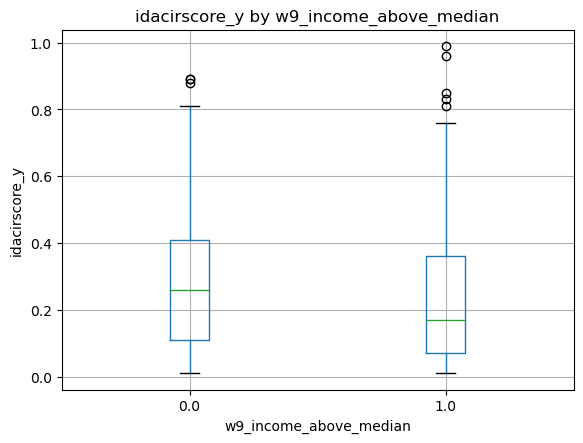

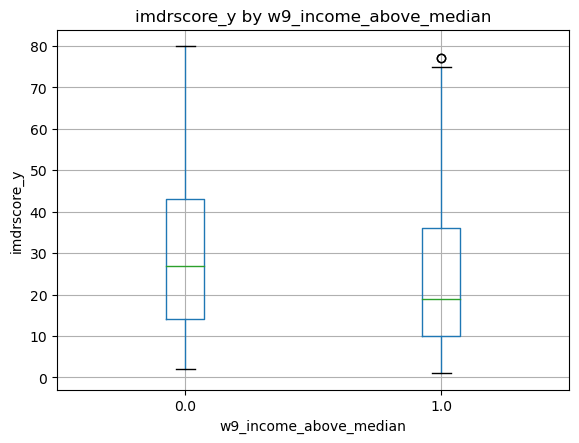

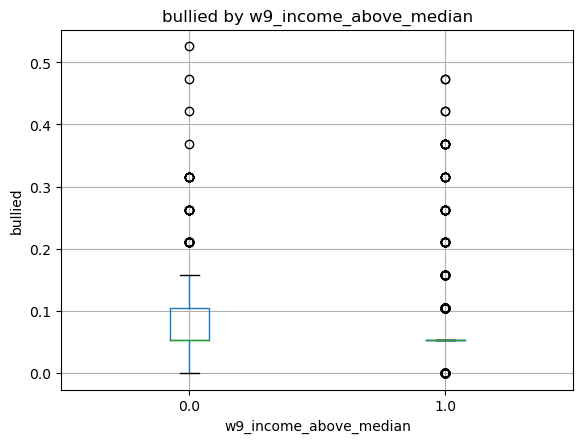

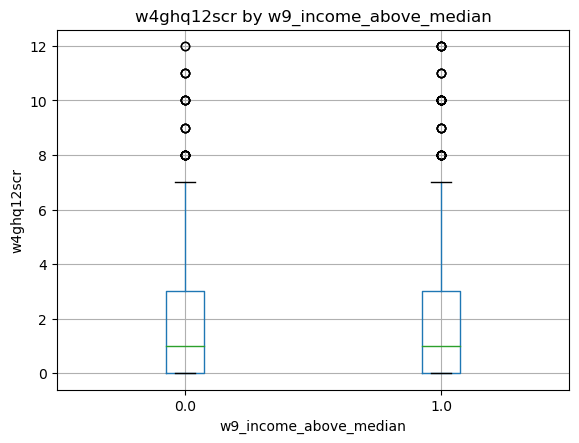

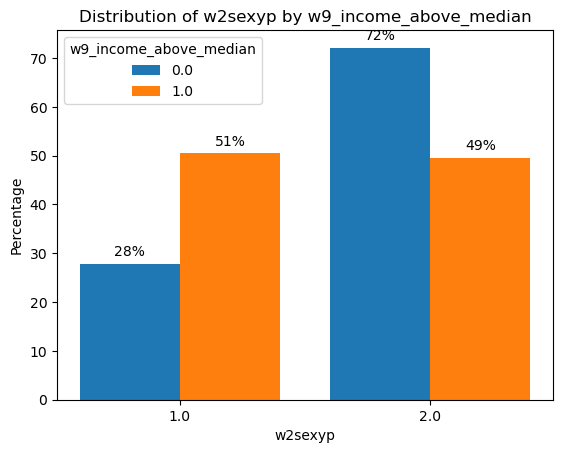

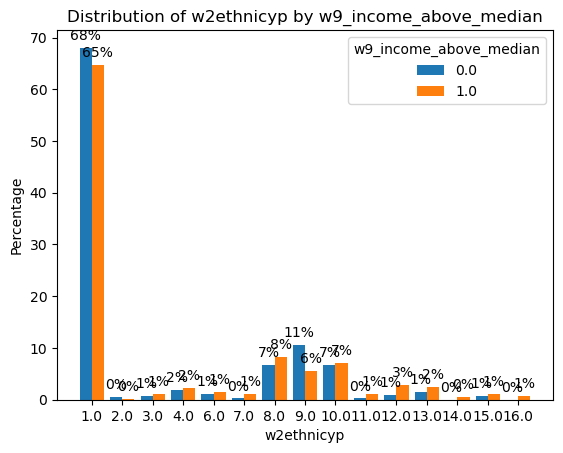

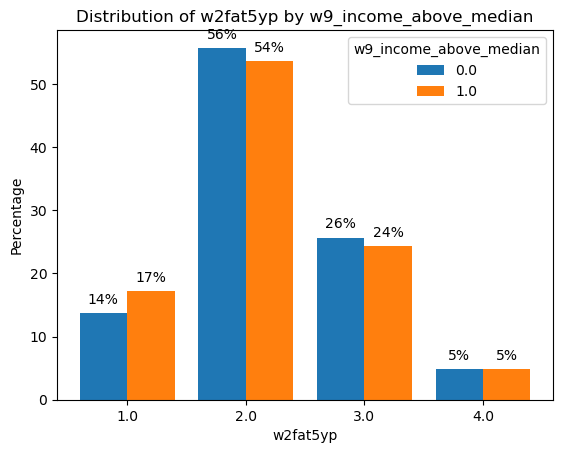

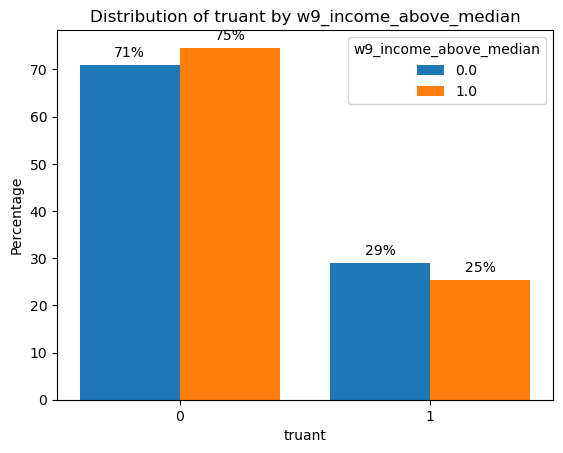

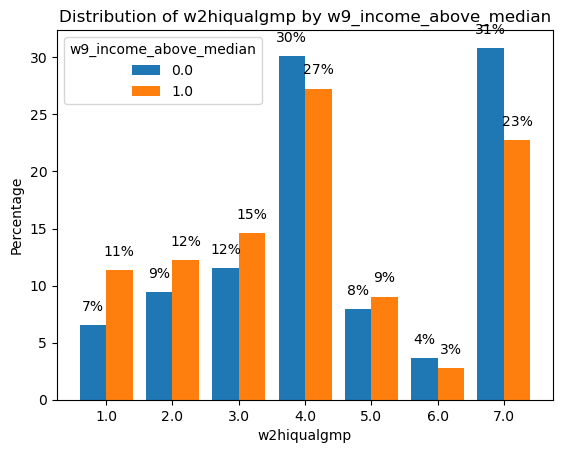

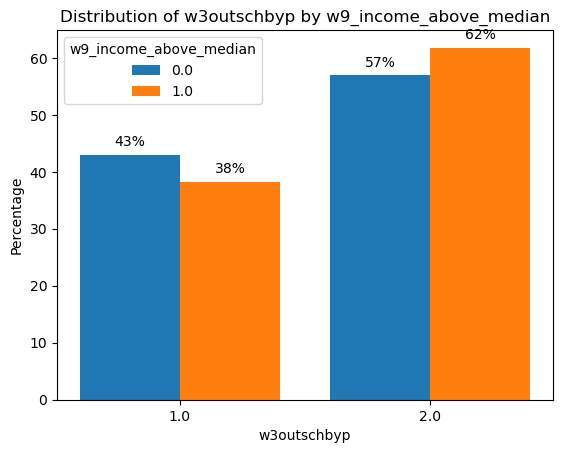

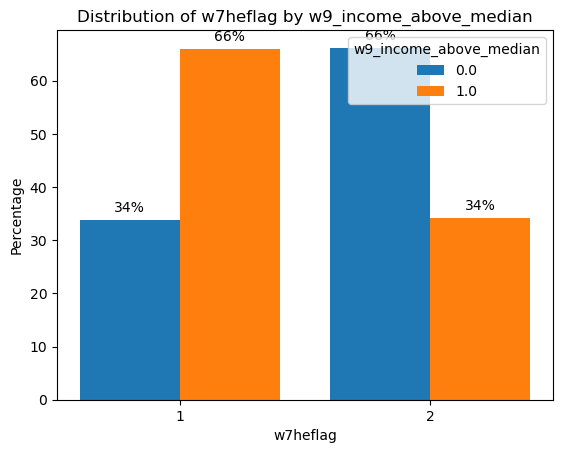

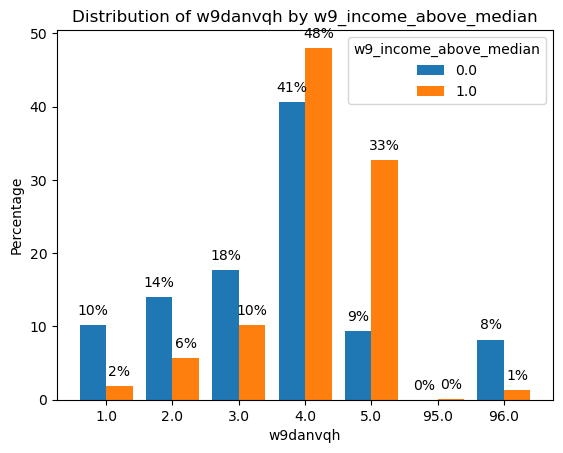

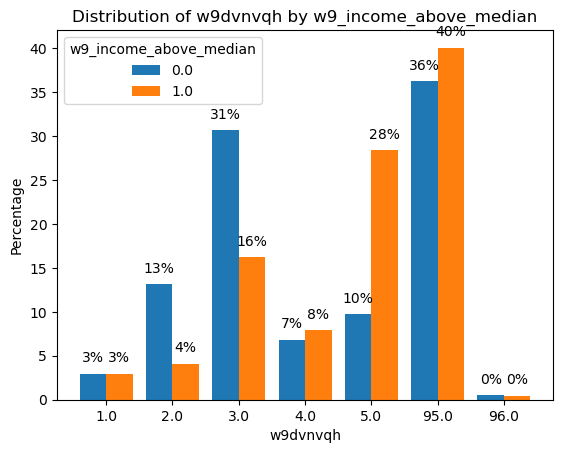

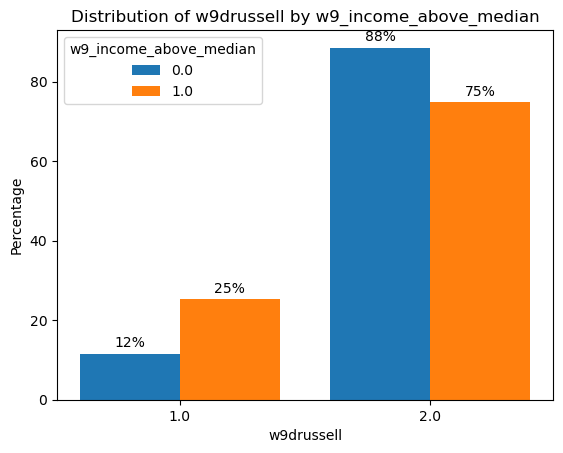

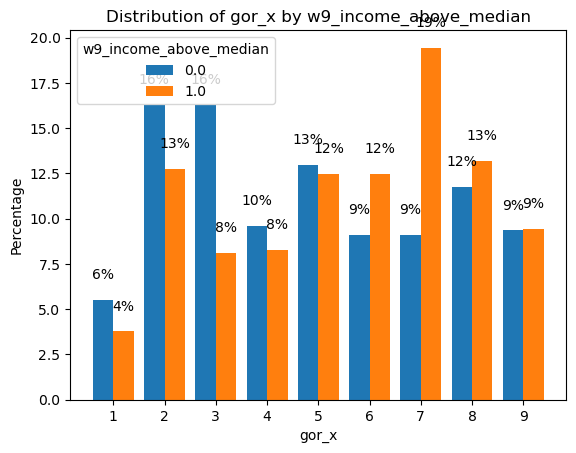

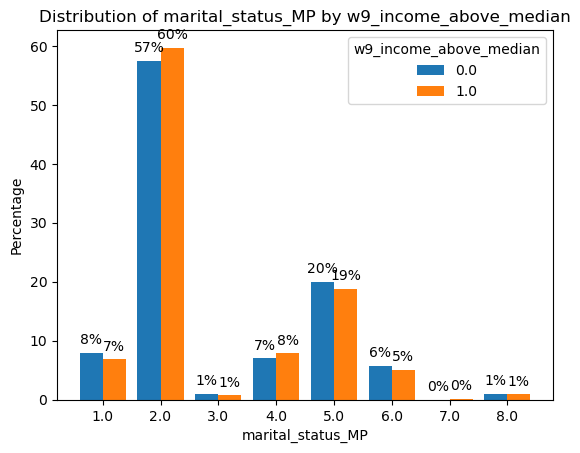

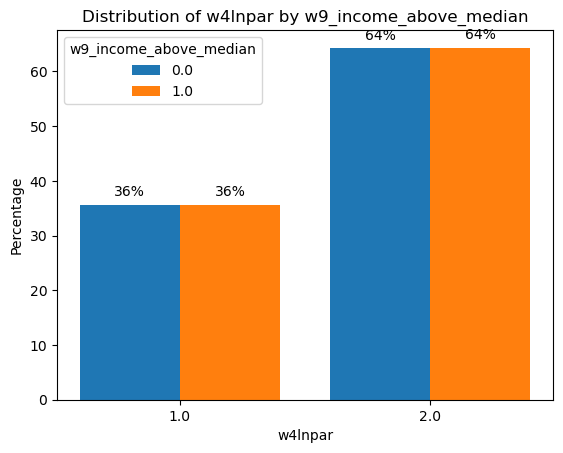

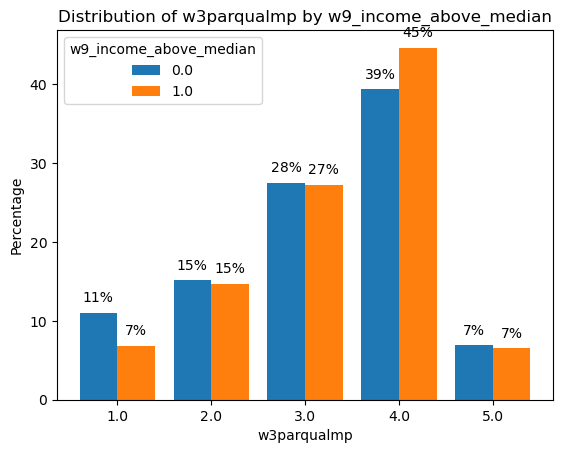

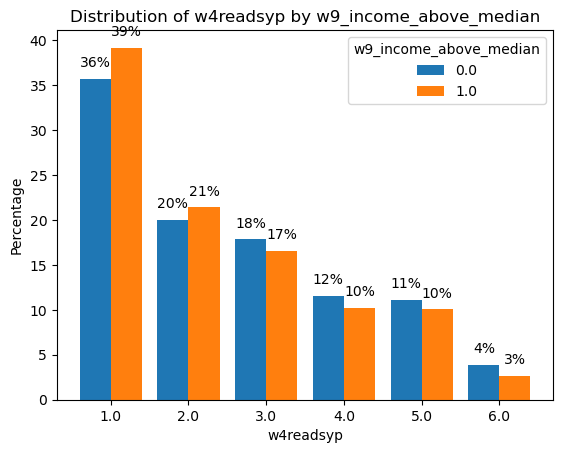

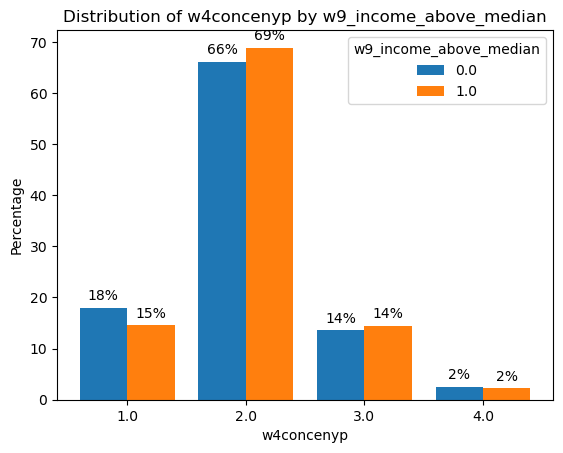

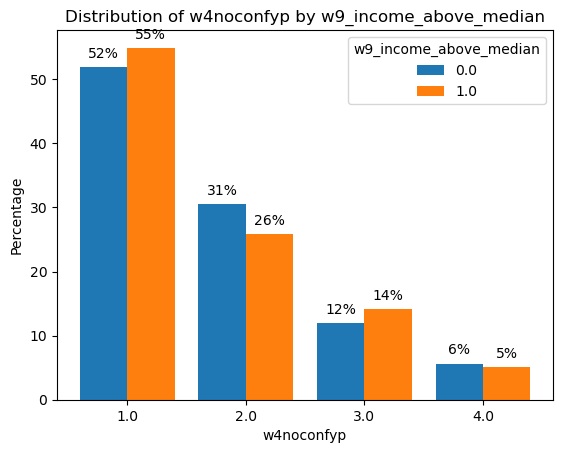

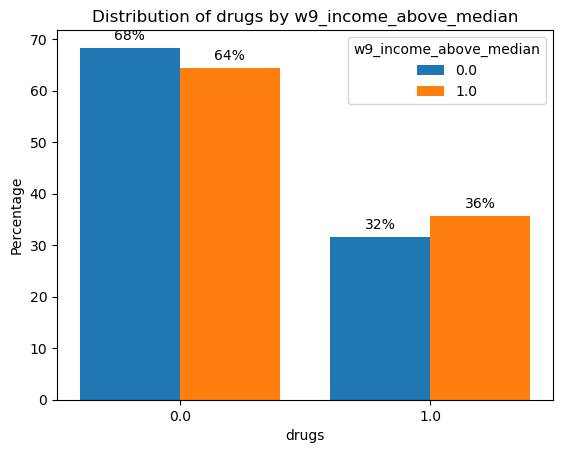

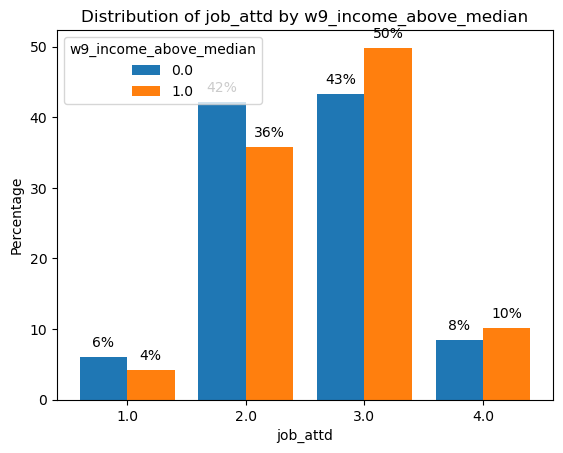

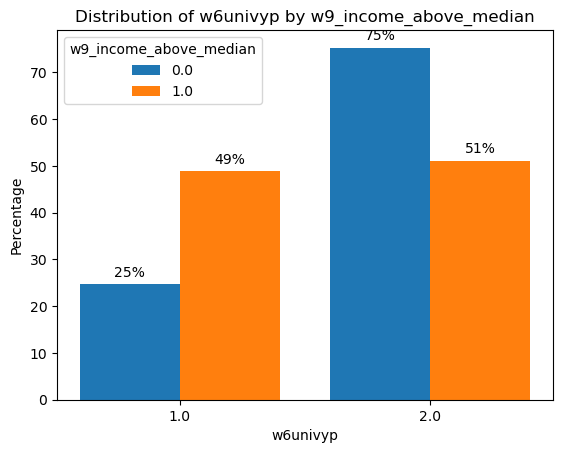

In [86]:
# 1. Define predictors
continuous_vars = ['idacirscore_y', 'imdrscore_y', 'bullied', 'w4ghq12scr']
# All other columns except the outcome
categorical_vars = [
    col
    for col in selected_vars
    if col not in continuous_vars and col != 'w9_income_cat'
]

# 1. Box plots for continuous predictors
for var in continuous_vars:
    fig, ax = plt.subplots()
    b40.boxplot(column=var, by='w9_income_above_median', ax=ax)
    ax.set_title(f'{var} by w9_income_above_median')
    ax.set_xlabel('w9_income_above_median')
    ax.set_ylabel(var)
    plt.suptitle('')
    plt.show()

# 2. Side-by-side bar charts for categorical predictors
for var in categorical_vars:
    # Compute percentage distribution within each income group
    ct = pd.crosstab(b40[var], b40['w9_income_above_median'], normalize='columns') * 100
    categories = ct.index.astype(str)
    x = np.arange(len(categories))
    n_groups = ct.shape[1]
    width = 0.8 / n_groups

    fig, ax = plt.subplots()
    for i, col in enumerate(ct.columns):
        heights = ct[col]
        bars = ax.bar(x + i*width, heights, width, label=f'{col}')
        # Annotate bars with percentage labels
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.0f}%', 
                    ha='center', va='bottom')

    ax.set_xticks(x + width*(n_groups-1)/2)
    ax.set_xticklabels(categories)
    ax.set_xlabel(var)
    ax.set_ylabel('Percentage')
    ax.set_title(f'Distribution of {var} by w9_income_above_median')
    ax.legend(title='w9_income_above_median')
    plt.show()
